# Winter wheat phenology — TorchCrop against the SAGE crop calendar (gridded)

**What this notebook does.** It bins the simulated sowing and maturity dates
onto the 0.5° grid of the Sacks et al. (2010) SAGE crop calendar and compares
them per cell — the gridded counterpart of
[`phenology_evaluation.ipynb`](phenology_evaluation.ipynb), with one important
difference: **SAGE reports a planting date**, not a green-up proxy that
changes meaning with climate the way CyBench's `sos` does. This is therefore
the more direct test of `config.SIM_SOWING_DOY`, the constant every cell in
the run is sown on.

## What each side contains

| Stage | TorchCrop | SAGE | Comparable? |
|---|---|---|---|
| Sowing | **constant input**, DOY 270 for every cell | `plant`, with a `plant.start`-`plant.end` window | yes — a genuine test of the constant |
| Flowering | **not in the run** | not in the calendar | no |
| Maturity | first day at `DVS ≥ 2` | `harvest`, with a `harvest.start`-`harvest.end` window | yes, with a harvest-after-maturity offset expected |

* **SAGE is a climatology.** One planting and harvest date per cell, assembled
  around 1990-2000 from agricultural-census and extension-service reports —
  no year dimension, so nothing here tests interannual skill, only whether the
  model places the *average* season in the right week.
* **A third of the domain is filled, not reported.** Where no reporting unit
  covers a cell, the `.fill` product extrapolates from the nearest one; those
  cells carry their donor's date exactly and are flagged `filled = True`
  throughout this notebook so they can be read separately.
* **A date comes with a window**, 10 to 100 days wide in Europe. Whether the
  simulated date falls **inside** that window is a more forgiving and more
  informative test than a bias in days, computed with `doy.doy_in_window`.

All reusable code is in [`utils/`](utils/); this notebook is the workflow only.

## 0. Setup

In [1]:
import logging
import sys
from pathlib import Path

# The notebooks live beside utils/, so they import it without installation.
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd

from utils import config, doy, grid, metrics, plots, torchcrop
from utils.style import use_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

PALETTE = use_style("light")
config.ensure_output_dirs()

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

print(f"TorchCrop run : {config.TORCHCROP_RUN_DIR}")
print(f"Outputs       : {config.OUTPUT_DIR}")
print(f"Grid          : {config.GRID_RES_DEG}° over {config.EUROPE_BBOX}")

TorchCrop run : /data01/FDS/muduchuru/Data/SIMPLACE/torchcrop/winter_wheat_2000_2024
Outputs       : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs
Grid          : 0.5° over (-11.0, 33.0, 34.0, 70.0)


## 1. Load the simulation and derive the stage dates, binned onto the SAGE grid

In [2]:
sim = torchcrop.load_simulation(columns=[
    "SimplaceID", "year", "lon", "lat", "days_to_maturity", "yield_t_ha",
    "biomass_g_m2", "max_lai", "tranrf_mean", "nni_mean", "heat_stress_factor",
])
sim = grid.crop_to_bbox(sim, config.EUROPE_BBOX)
# Tagged onto every 10 km row (not just the binned means) so the diagnostics
# in §7 can group the run's own state variables by 0.5° cell too.
sim["grid_id"] = grid.grid_cell_id(*grid.snap_to_grid(sim["lon"], sim["lat"]))

sim_grid = grid.bin_cells(
    sim, {"sowing_doy": True, "maturity_doy": True, "season_length_days": False},
)
# `season_length_days` exists on both sides once paired with the SAGE calendar
# (its own `tot.days`); rename the simulated one now rather than disambiguate
# a pandas merge suffix later.
sim_grid = sim_grid.rename(columns={"season_length_days": "sim_season_length_days"})

print(f"{len(sim):,} cell-seasons on the 10 km grid -> "
      f"{len(sim_grid):,} 0.5° cells, "
      f"{sim_grid['n_cells'].median():.0f} simulated cells per cell (median)")
sim_grid.describe().T

INFO utils.torchcrop: read torchcrop_europe.parquet: 1717125 rows, 11 columns
WARNING utils.torchcrop: 70 of 1717125 rows (0.00%) never reached maturity; their dates are NaN
INFO utils.grid: binned 1109225 rows into 2677 0.5-degree groups (249 dropped below 3 cells)


1,109,225 cell-seasons on the 10 km grid -> 2,428 0.5° cells, 22 simulated cells per cell (median)


,count,mean,std,min,25%,50%,75%,max
grid_id,2428.0,198367.215404,9243.774719,178907.000000,191181.750000,199122.500000,205560.250000,220005.000000
lon,2428.0,14.236614,11.768406,-9.250000,3.750000,15.250000,24.750000,32.750000
lat,2428.0,47.735585,6.415804,34.250000,42.750000,48.250000,52.750000,62.750000
sowing_doy,2428.0,270.000000,0.000000,270.000000,270.000000,270.000000,270.000000,270.000000
maturity_doy,2428.0,160.224240,44.728849,27.382708,137.446258,168.065161,192.339672,253.037446
sim_season_length_days,2428.0,255.212892,44.728586,122.372000,232.400800,263.033600,287.328000,348.674556
n_cells,2428.0,18.129736,7.512882,3.000000,12.000000,22.000000,25.000000,25.000000


## 2. Load the SAGE calendar

In [3]:
from utils import sage

calendar = sage.load_sage_calendar(crop=config.SAGE_CROP)
print(f"SAGE crop: {config.SAGE_CROP} ({config.SAGE_ROOT})")
print(f"{len(calendar):,} cells in the domain, "
      f"{100 * calendar['filled'].mean():.0f}% filled from a neighbouring unit")
calendar.describe().T

INFO utils.sage: SAGE Wheat.Winter: 3688 cells in the domain, 1280 (35%) filled from a neighbour


SAGE crop: Wheat.Winter (/data01/FDS/muduchuru/Data/Agri/SAGE_crop_calendar)
3,688 cells in the domain, 35% filled from a neighbouring unit


,count,mean,std,min,25%,50%,75%,max
grid_id,3688.0,203672.694685,13506.027949,178906.00,193328.75,202727.50,214254.25,230105.00
lon,3688.0,15.263286,11.693489,-10.25,6.75,16.75,25.25,32.75
lat,3688.0,51.418520,9.373803,34.25,44.25,50.75,58.75,69.75
plant,3688.0,284.992828,25.474617,242.00,259.00,275.50,303.50,339.00
plant_start,3688.0,256.649414,22.215073,232.00,242.00,243.00,272.00,315.00
plant_end,3688.0,302.647491,56.362217,20.00,284.00,307.00,334.00,365.00
harvest,3688.0,199.839615,19.522291,134.50,181.50,209.50,213.00,227.50
harvest_start,3459.0,172.395493,22.674669,107.00,151.00,182.00,192.00,209.00
harvest_end,3459.0,226.203232,18.414923,162.00,211.00,233.00,240.00,251.00
plant_range_days,3688.0,57.686822,15.266756,10.00,51.00,64.00,64.00,102.00


## 3. Pair the two sides

A plain join on `grid_id` — SAGE carries no year, so every simulated season in
a cell is compared against the same climatological date, exactly as CyBench's
`sos`/`eos` are in the country-level notebook.

In [4]:
paired = grid.pair_gridded(sim_grid, calendar, ["grid_id"])

for stage in config.CALENDAR_STAGES:
    paired[f"{stage.key}_error"] = doy.doy_difference(
        paired[stage.sim_col], paired[stage.obs_col]
    )
    paired[f"{stage.key}_in_window"] = doy.doy_in_window(
        paired[stage.sim_col], paired[stage.start_col], paired[stage.end_col]
    )

print(f"{len(paired):,} paired 0.5° cells, "
      f"{100 * paired['filled'].mean():.0f}% filled")
paired.head()

INFO utils.grid: paired 2379 rows; 49 simulated-only and 1309 observed-only dropped


2,379 paired 0.5° cells, 21% filled


,grid_id,lon,lat,sowing_doy,maturity_doy,sim_season_length_days,n_cells,plant,plant_start,plant_end,...,harvest_start,harvest_end,plant_range_days,harvest_range_days,season_length_days,filled,sowing_error,sowing_in_window,maturity_error,maturity_in_window
0,178907,-6.25,34.25,270.0,35.332174,130.3250,16,335.0,315.0,355.0,...,132.0,172.0,41.0,41.0,182.0,False,-65.0,False,-116.667826,False
1,178908,-5.75,34.25,270.0,37.055150,132.0512,25,335.0,315.0,355.0,...,132.0,172.0,41.0,41.0,182.0,False,-65.0,False,-114.944850,False
2,178909,-5.25,34.25,270.0,41.765159,136.7888,25,335.0,315.0,355.0,...,132.0,172.0,41.0,41.0,182.0,False,-65.0,False,-110.234841,False
3,178910,-4.75,34.25,270.0,45.792284,140.7824,25,335.0,315.0,355.0,...,132.0,172.0,41.0,41.0,182.0,False,-65.0,False,-106.207716,False
4,178911,-4.25,34.25,270.0,66.026376,161.1500,20,335.0,315.0,355.0,...,132.0,172.0,41.0,41.0,182.0,False,-65.0,False,-85.973624,False


## 4. Metrics by stage

Reported once pooled and once restricted to the reported (non-filled) cells —
the filled third of the domain repeats a neighbour's exact date, which can
only make a local bias look smoother than it is.

In [5]:
pooled = {}
reported = paired[~paired["filled"]]
for stage in config.CALENDAR_STAGES:
    pooled[stage.label] = metrics.phenology_metrics(paired[stage.obs_col], paired[stage.sim_col])
    pooled[f"{stage.label} (reported only)"] = metrics.phenology_metrics(
        reported[stage.obs_col], reported[stage.sim_col]
    )

pooled_table = pd.DataFrame(pooled).T[list(metrics.PHENOLOGY_METRIC_ORDER)]
pooled_table["observed date"] = pooled_table["obs_mean"].map(doy.doy_to_month_day)
pooled_table["simulated date"] = pooled_table["sim_mean"].map(doy.doy_to_month_day)
pooled_table.round(2)

,n,obs_mean,sim_mean,bias,mae,rmse,pearson_r,observed date,simulated date
Sowing,2379.0,288.25,270.00,-18.33,25.83,31.96,NaN,15 Oct,27 Sep
Sowing (reported only),1876.0,291.45,270.00,-21.48,26.58,32.88,NaN,18 Oct,27 Sep
Maturity / harvest,2379.0,201.82,164.44,-40.71,44.74,54.88,0.57,20 Jul,13 Jun
Maturity / harvest (reported only),1876.0,202.13,159.63,-45.43,48.41,57.79,0.56,21 Jul,8 Jun


In [6]:
for stage in config.CALENDAR_STAGES:
    print(f"--- {stage.label} ---")
    print(stage.caveat)
    print()

--- Sowing ---
A like-for-like pairing of a constant against a field. SAGE 'plant' is a planting date, which is what DOY 270 is meant to be — unlike CyBench 'sos', which switches between an autumn sowing and a spring green-up with climate. The bias therefore measures the run's single sowing latch honestly, and the residual field is exactly the sowing calendar the export is missing.

--- Maturity / harvest ---
Simulated maturity is the first day at DVS >= 2; SAGE 'harvest' is the date the crop is taken off the field, which is at or after maturity. The residual absorbs that interval, so a small positive bias is not necessarily an error.



### Window containment

The share of cells whose simulated date falls inside the SAGE window, split
into "too early", "inside" and "too late" — the categorical answer the bias
figures below cannot give on their own.

In [7]:
window_summary = {}
for stage in config.CALENDAR_STAGES:
    position = doy.window_position(paired[stage.sim_col], paired[stage.start_col],
                                   paired[stage.end_col])
    category = np.select(
        [position < 0, position == 0, position > 0],
        ["before window", "in window", "after window"],
        default="not paired",
    )
    paired[f"{stage.key}_position"] = category
    counts = pd.Series(category).value_counts(normalize=True) * 100
    window_summary[stage.label] = counts

pd.DataFrame(window_summary).round(1).fillna(0.0)

,Sowing,Maturity / harvest
after window,9.4,3.0
before window,48.2,60.6
in window,42.4,27.0
not paired,0.0,9.4


## 5. Figures

### 5.1 Observed against simulated, one panel per stage

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/sage_01_scatter_sowing(.png/.pdf)


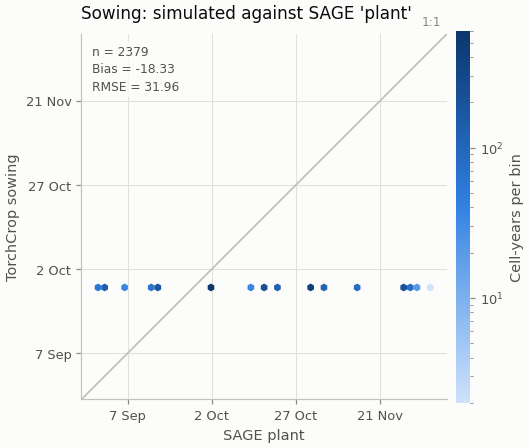

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/sage_01_scatter_maturity(.png/.pdf)


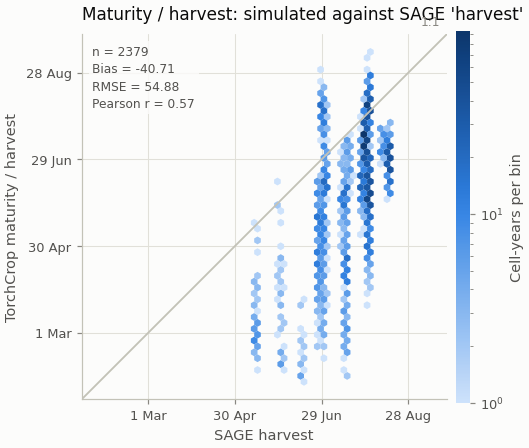

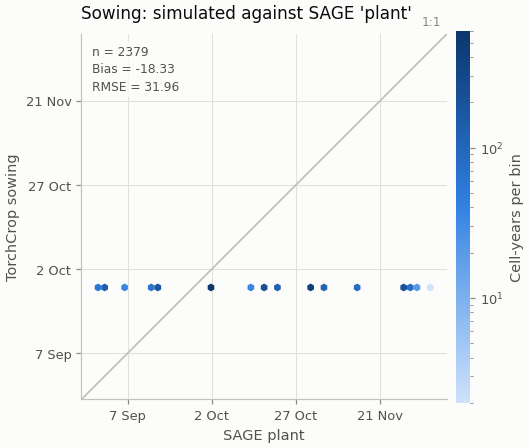

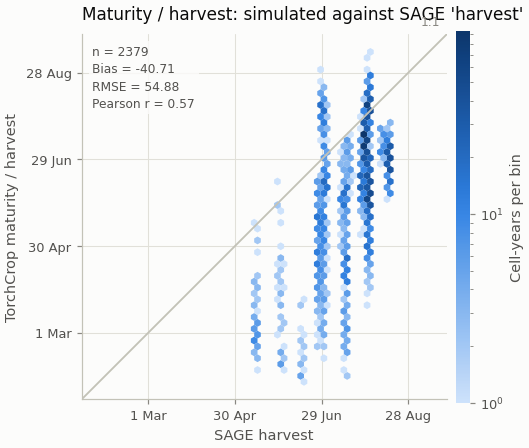

In [8]:
for stage in config.CALENDAR_STAGES:
    fig = plots.scatter_density(
        paired, stage.obs_col, stage.sim_col, circular=True,
        stats=pooled[stage.label], metric_keys=("n", "bias", "rmse", "pearson_r"),
        title=f"{stage.label}: simulated against SAGE '{stage.obs_col}'",
        xlabel=f"SAGE {stage.obs_col}", ylabel=f"TorchCrop {stage.label.lower()}",
    )
    plots.save(fig, f"sage_01_scatter_{stage.key}")
    display(fig)

### 5.2 Bias maps

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/sage_02_map_bias_sowing(.png/.pdf)
INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/sage_02_map_bias_maturity(.png/.pdf)


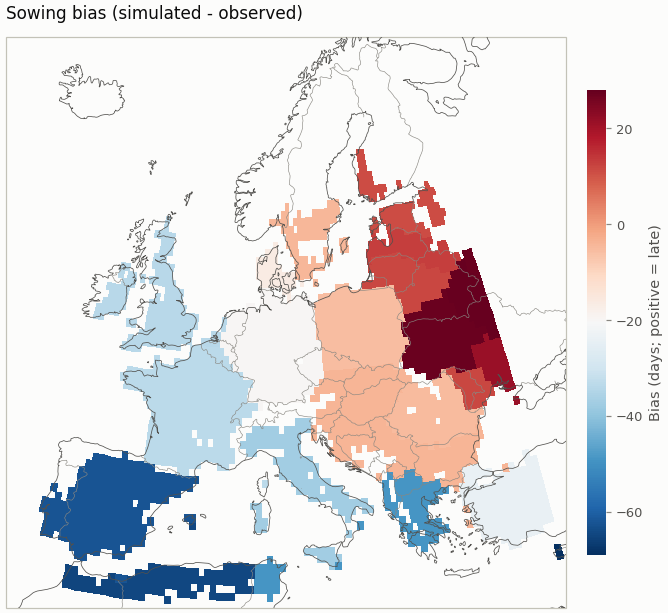

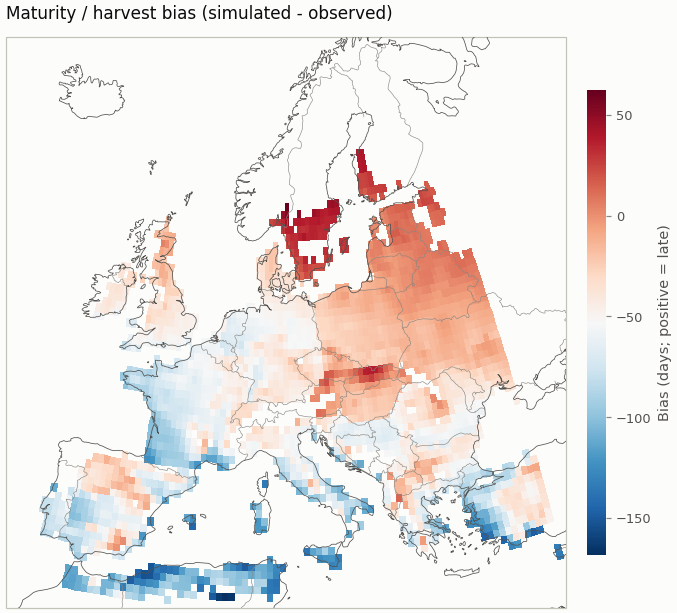

In [9]:
for stage in config.CALENDAR_STAGES:
    stage_paired = paired.dropna(subset=[f"{stage.key}_error"])
    fig = plots.cell_map(
        stage_paired, f"{stage.key}_error",
        title=f"{stage.label} bias (simulated - observed)",
        cbar_label="Bias (days; positive = late)", cmap="RdBu_r",
    )
    plots.save(fig, f"sage_02_map_bias_{stage.key}")
    # display(fig)

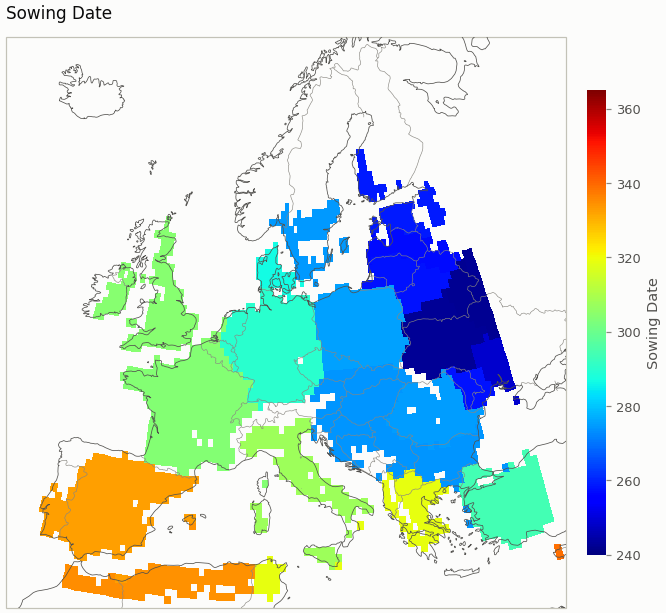

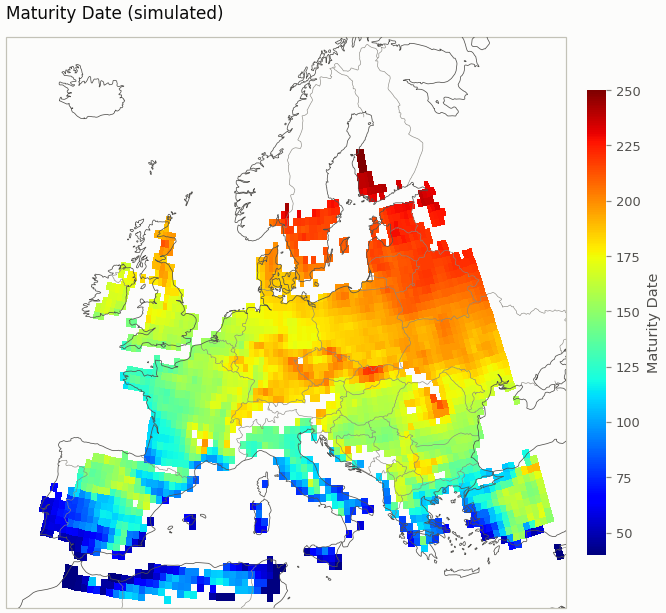

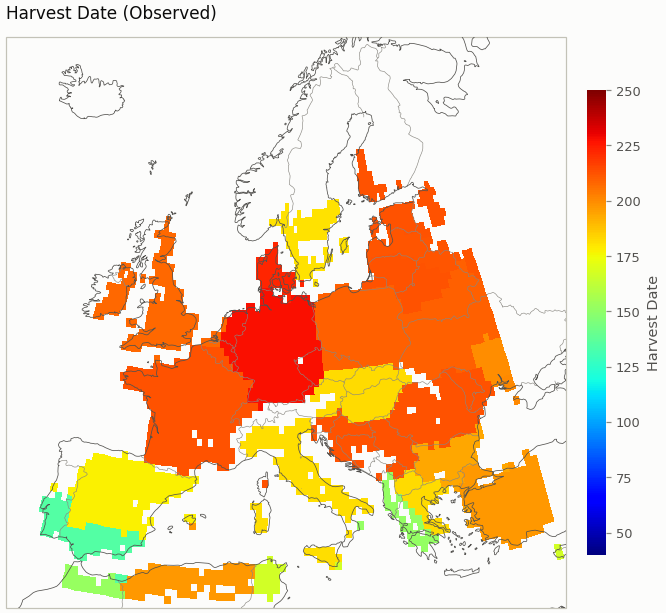

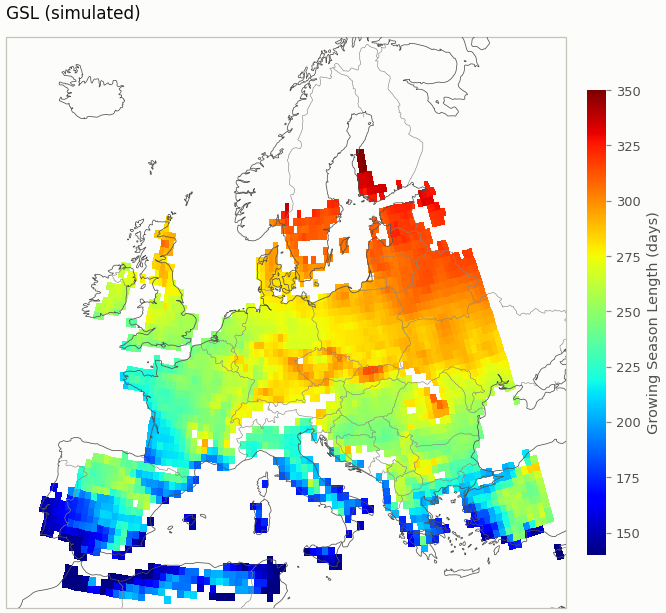

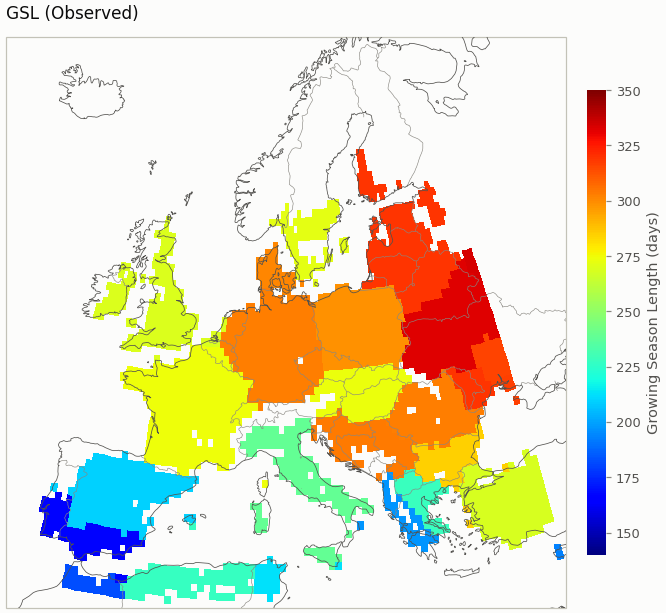

In [29]:
stage_paired = paired.dropna(subset=[f"plant"])
fig = plots.cell_map(
    stage_paired, f"plant",
    title=f"Sowing Date",
    cbar_label="Sowing Date", cmap="jet",
    vmin=240, vmax=365,
)

stage_paired = paired.dropna(subset=[f"maturity_doy"])
fig = plots.cell_map(
    stage_paired, f"maturity_doy",
    title=f"Maturity Date (simulated)",
    cbar_label="Maturity Date", cmap="jet",
    vmin=40, vmax=250,
)

stage_paired = paired.dropna(subset=[f"harvest"])
fig = plots.cell_map(
    stage_paired, f"harvest",
    title=f"Harvest Date (Observed)",
    cbar_label="Harvest Date", cmap="jet",
    vmin=40, vmax=250,
)

stage_paired = paired.dropna(subset=[f"sim_season_length_days"])
fig = plots.cell_map(
    stage_paired, f"sim_season_length_days",
    title=f"GSL (simulated)",
    cbar_label="Growing Season Length (days)", cmap="jet",
    vmin=140, vmax=350,
)

stage_paired = paired.dropna(subset=[f"season_length_days"])
fig = plots.cell_map(
    stage_paired, f"season_length_days",
    title=f"GSL (Observed)",
    cbar_label="Growing Season Length (days)", cmap="jet",
    vmin=140, vmax=350,
)
# plots.save(fig, f"sage_02_map_bias_{stage.key}")

In [27]:
paired

,grid_id,lon,lat,sowing_doy,maturity_doy,sim_season_length_days,n_cells,plant,plant_start,plant_end,...,plant_range_days,harvest_range_days,season_length_days,filled,sowing_error,sowing_in_window,maturity_error,maturity_in_window,sowing_position,maturity_position
0,178907,-6.25,34.25,270.0,35.332174,130.325000,16,335.0,315.0,355.0,...,41.0,41.0,182.0,False,-65.0,False,-116.667826,False,before window,before window
1,178908,-5.75,34.25,270.0,37.055150,132.051200,25,335.0,315.0,355.0,...,41.0,41.0,182.0,False,-65.0,False,-114.944850,False,before window,before window
2,178909,-5.25,34.25,270.0,41.765159,136.788800,25,335.0,315.0,355.0,...,41.0,41.0,182.0,False,-65.0,False,-110.234841,False,before window,before window
3,178910,-4.75,34.25,270.0,45.792284,140.782400,25,335.0,315.0,355.0,...,41.0,41.0,182.0,False,-65.0,False,-106.207716,False,before window,before window
4,178911,-4.25,34.25,270.0,66.026376,161.150000,20,335.0,315.0,355.0,...,41.0,41.0,182.0,False,-65.0,False,-85.973624,False,before window,before window
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,217844,22.25,61.25,270.0,237.776851,332.834286,7,259.0,234.0,284.0,...,51.0,43.0,319.0,True,11.0,True,24.776851,False,in window,after window
2375,217845,22.75,61.25,270.0,238.779701,333.850000,4,259.0,234.0,284.0,...,51.0,43.0,319.0,True,11.0,True,25.779701,False,in window,after window
2376,217846,23.25,61.25,270.0,241.446458,336.537143,7,259.0,234.0,284.0,...,51.0,43.0,319.0,True,11.0,True,28.446458,False,in window,after window
2377,220004,22.25,62.75,270.0,251.510453,347.064000,5,259.0,234.0,284.0,...,51.0,43.0,319.0,True,11.0,True,38.510453,False,in window,after window


### 5.3 Window containment maps

Discrete fills rather than a colour ramp: "inside the window" has no useful
distance to "before" or "after" it.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/sage_03_map_window_sowing(.png/.pdf)


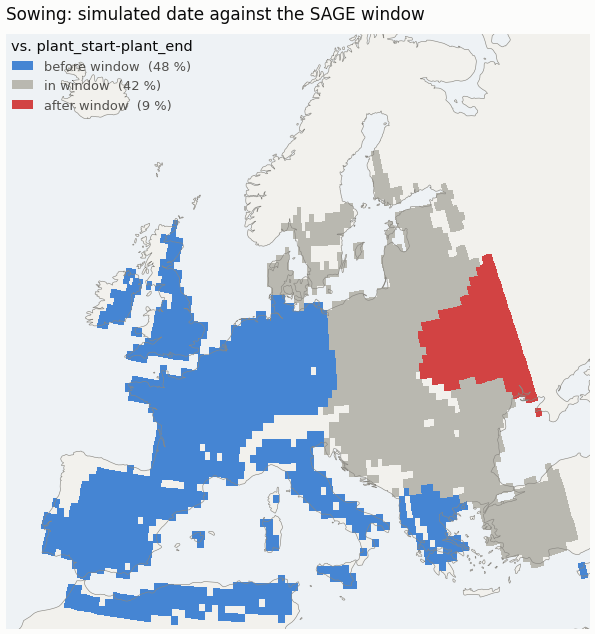

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/sage_03_map_window_maturity(.png/.pdf)


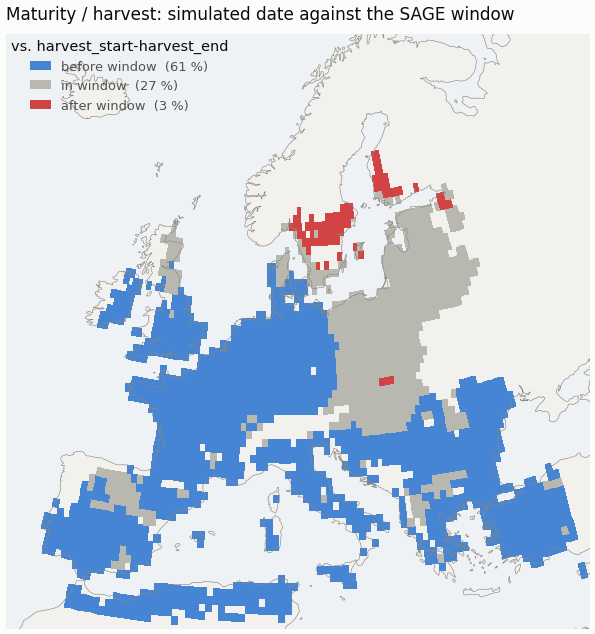

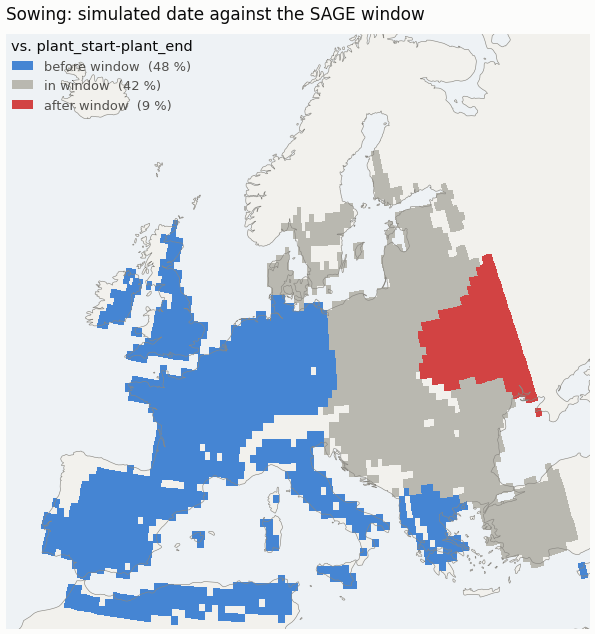

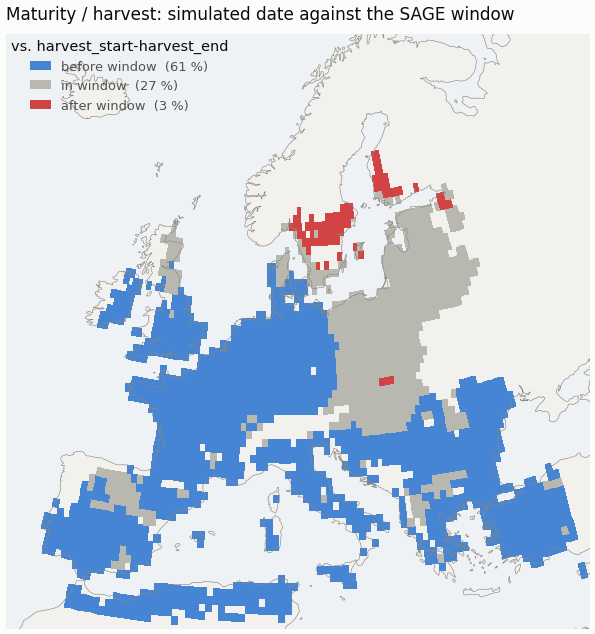

In [12]:
for stage in config.CALENDAR_STAGES:
    fig = plots.category_map(
        paired, f"{stage.key}_position",
        categories=["before window", "in window", "after window"],
        title=f"{stage.label}: simulated date against the SAGE window",
        legend_title=f"vs. {stage.start_col}-{stage.end_col}",
    )
    plots.save(fig, f"sage_03_map_window_{stage.key}")
    display(fig)

### 5.4 Season length

`sim_season_length_days` is sowing-to-maturity; SAGE's `season_length_days` is
planting-to-harvest. The two are not the same interval — this compares their
*durations*, not the dates that bound them, so it survives the DOY 270 sowing
offset entirely.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/sage_04_scatter_season_length(.png/.pdf)


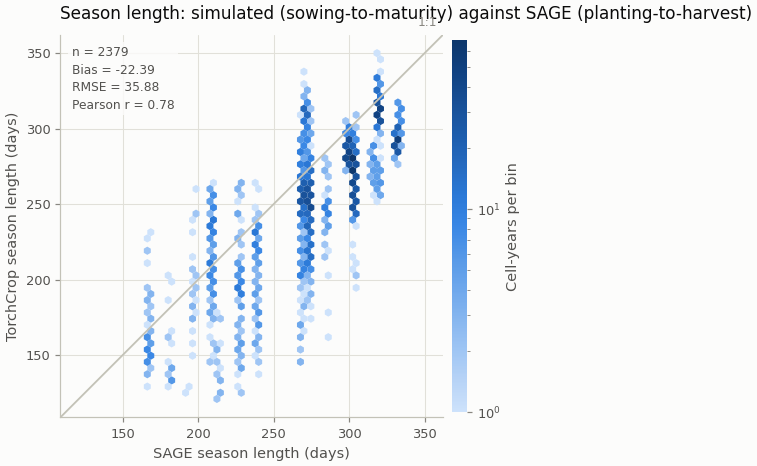

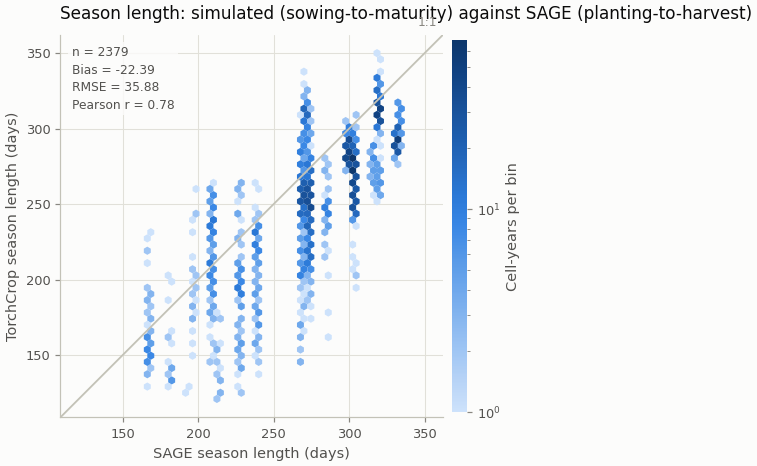

In [13]:
season_pooled = metrics.yield_metrics(
    paired["season_length_days"], paired["sim_season_length_days"]
)
fig = plots.scatter_density(
    paired, "season_length_days", "sim_season_length_days", stats=season_pooled,
    metric_keys=("n", "bias", "rmse", "pearson_r"),
    title="Season length: simulated (sowing-to-maturity) against SAGE (planting-to-harvest)",
    xlabel="SAGE season length (days)", ylabel="TorchCrop season length (days)",
)
plots.save(fig, "sage_04_scatter_season_length")
fig

## 6. Error decomposition — how much of the maturity error is the sowing offset

The run's maturity date is `sowing_doy + days_to_maturity`. If sowing is early
by `X` days and the simulated season length is otherwise right, maturity is
early by about `X` days too — a sowing artefact, not a growth-rate error. This
splits the maturity bias into the two additive pieces so the difference is
visible rather than absorbed into one number.

Mean absolute contribution to the maturity error:
Sowing offset             25.83
Season-length residual    29.31


INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/sage_05_bars_decomposition(.png/.pdf)


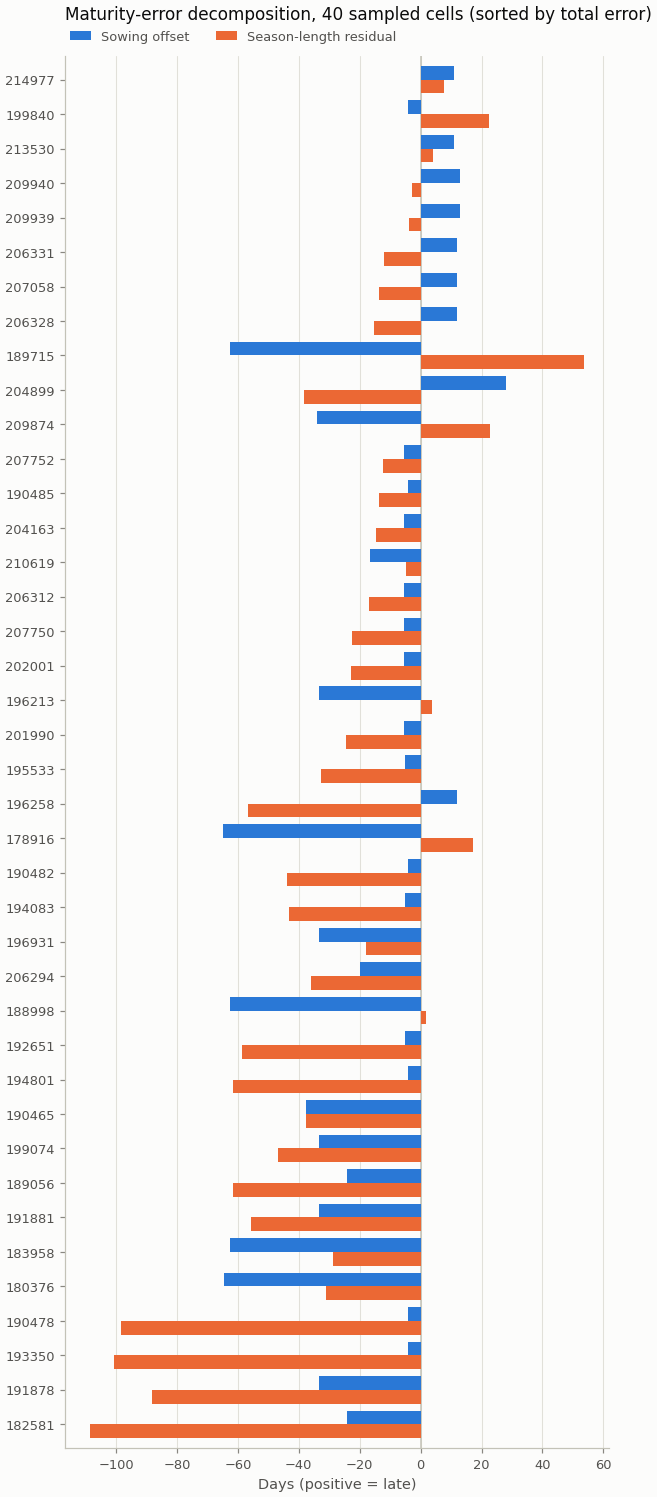

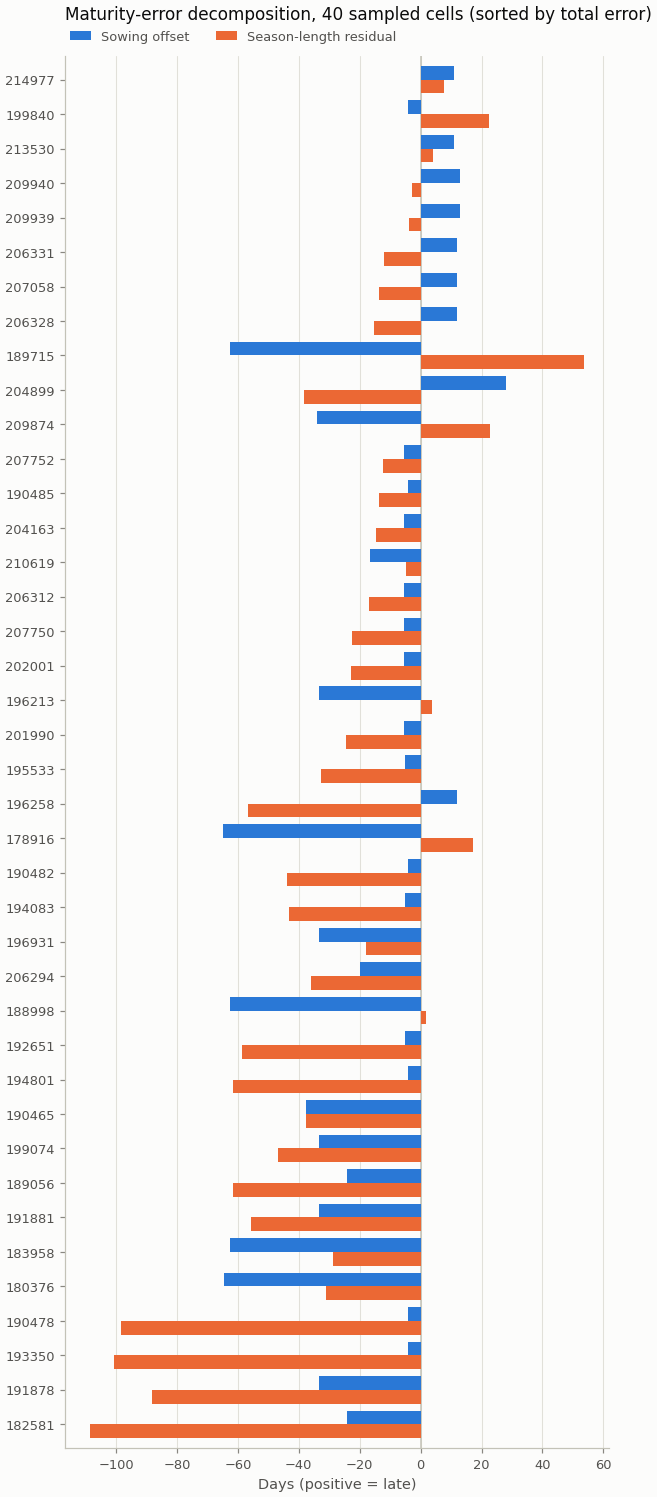

In [14]:
# `paired` is already one row per grid_id (SAGE carries no year), so this is a
# rename, not an aggregation.
decomposition = pd.DataFrame({
    "Sowing offset": paired["sowing_error"].to_numpy(),
    "Season-length residual": (paired["maturity_error"] - paired["sowing_error"]).to_numpy(),
}, index=paired["grid_id"].to_numpy())
decomposition.index.name = "grid_id"
decomposition["Maturity error (total)"] = (
    decomposition["Sowing offset"] + decomposition["Season-length residual"]
)

print("Mean absolute contribution to the maturity error:")
print(decomposition[["Sowing offset", "Season-length residual"]].abs().mean().round(2).to_string())

fig = plots.component_bars(
    decomposition.sample(min(40, len(decomposition)), random_state=0)
                .sort_values("Maturity error (total)"),
    ["Sowing offset", "Season-length residual"],
    title="Maturity-error decomposition, 40 sampled cells (sorted by total error)",
    xlabel="Days (positive = late)",
)
plots.save(fig, "sage_05_bars_decomposition")
fig

## 7. Diagnostics — the run's own state next to the bias

In [15]:
state = (
    sim.groupby("grid_id", as_index=False)
    .agg(lon=("lon", "first"), lat=("lat", "first"),
         max_lai=("max_lai", "mean"), biomass=("biomass_g_m2", "mean"),
         days_to_maturity=("days_to_maturity", "mean"),
         water_stress=("tranrf_mean", "mean"), n_index=("nni_mean", "mean"),
         heat=("heat_stress_factor", "mean"),
         failed_share=("yield_t_ha", lambda s: float((s < 0.5).mean())))
)

state["maturity_bias"] = state["grid_id"].map(paired.set_index("grid_id")["maturity_error"])
state["sowing_bias"] = state["grid_id"].map(paired.set_index("grid_id")["sowing_error"])
state = state.dropna(subset=["maturity_bias"])

print("Correlation of cell maturity bias with the run's own state variables:")
print(state.corr(numeric_only=True)["maturity_bias"]
      .drop(["maturity_bias", "sowing_bias"]).round(2).sort_values().to_string())
state.round(2).head()

Correlation of cell maturity bias with the run's own state variables:
n_index            -0.39
failed_share       -0.37
heat                0.21
max_lai             0.36
lon                 0.43
water_stress        0.48
biomass             0.57
grid_id             0.74
lat                 0.74
days_to_maturity    0.90


,grid_id,lon,lat,max_lai,biomass,days_to_maturity,water_stress,n_index,heat,failed_share,maturity_bias,sowing_bias
1,178907,-6.35,34.349998,0.76,132.850006,130.320007,0.70,0.96,0.0,0.54,-116.67,-65.0
2,178908,-5.65,34.450001,0.54,98.660004,132.050003,0.67,0.97,0.0,0.58,-114.94,-65.0
3,178909,-5.35,34.349998,0.53,92.290001,136.789993,0.63,0.98,0.0,0.57,-110.23,-65.0
4,178910,-4.65,34.450001,0.58,108.080002,140.779999,0.64,0.97,0.0,0.51,-106.21,-65.0
5,178911,-4.35,34.349998,1.02,167.630005,161.149994,0.66,0.97,0.0,0.39,-85.97,-65.0


## 8. Summary

In [16]:
summary = pd.Series({
    "0.5-degree cells": paired["grid_id"].nunique(),
    "filled share (%)": round(100 * paired["filled"].mean(), 1),
    "sowing bias (days)": round(pooled["Sowing"]["bias"], 1),
    "sowing RMSE (days)": round(pooled["Sowing"]["rmse"], 1),
    "sowing in-window (%)": round(
        100 * paired["sowing_in_window"].mean(), 1),
    "maturity bias (days)": round(pooled["Maturity / harvest"]["bias"], 1),
    "maturity RMSE (days)": round(pooled["Maturity / harvest"]["rmse"], 1),
    "maturity Pearson r": round(pooled["Maturity / harvest"]["pearson_r"], 2),
    "season-length bias (days)": round(season_pooled["bias"], 1),
    "season-length RMSE (days)": round(season_pooled["rmse"], 1),
}, name="value")

paired.to_csv(config.TABLE_DIR / "sage_paired_cell.csv", index=False, float_format="%.4f")
pooled_table.to_csv(config.TABLE_DIR / "sage_metrics_pooled.csv", float_format="%.3f")
state.to_csv(config.TABLE_DIR / "sage_diagnostics_by_cell.csv", float_format="%.4f")
print(f"tables written to {config.TABLE_DIR}")
print(f"figures written to {config.FIGURE_DIR}")
summary.to_frame()

tables written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/tables
figures written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures


,value
0.5-degree cells,2379.00
filled share (%),21.10
sowing bias (days),-18.30
sowing RMSE (days),32.00
sowing in-window (%),42.40
maturity bias (days),-40.70
maturity RMSE (days),54.90
maturity Pearson r,0.57
season-length bias (days),-22.40
season-length RMSE (days),35.90


### What the numbers mean, and what they do not

* **Sowing is the genuine result here, unlike in the CyBench notebook.** SAGE
  `plant` does not switch convention with climate the way CyBench `sos` does,
  so this bias is a direct, continent-wide statement about the DOY 270 latch —
  and §5.3/§6 say where and by how much a real sowing calendar would have to
  differ from that constant.
* **The window test and the bias are complementary, not redundant.** A cell can
  be "in window" with a large bias if the window is wide, and "out of window"
  with a small one if the window is narrow — read both.
* **Maturity still carries the CyBench notebook's caveat**: SAGE `harvest` is
  at or after `DVS = 2`, so part of the bias is that interval, not model error.
  §6's decomposition only separates the sowing contribution from the rest; it
  does not remove the harvest-after-maturity gap.
* **A third of the domain is a repeated neighbour's date, not an independent
  observation.** The `filled` split in §4 is there so a result is not quoted
  from a part of the map that is smoother than the underlying data.
* **The reference is climatological**, exactly as CyBench's calendar is:
  nothing here tests interannual timing, only the average placement of the
  season.